检测系统配置

In [1]:
import os
print('CPU可用核心数:',os.cpu_count())

CPU可用核心数: 52


In [2]:
#获取GPU可用性
import tensorflow as tf
print('GPU可用性:',tf.test.is_gpu_available())
print("可用GPU数: ", len(tf.config.experimental.list_physical_devices('GPU')))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU可用性: True
可用GPU数:  2


2025-08-28 11:02:46.347012: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-28 11:02:48.333687: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:65:03.0, compute capability: 7.0
2025-08-28 11:02:48.335095: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:04.0, compute capability: 7.0


加载数据并设置数据管道

In [3]:
#读取文件地址
import pandas as pd
ImageFile=pd.read_csv('/root/StrokeDataset/ImageFiles.csv')

In [4]:
#分割数据集+分层抽样
from sklearn.model_selection import train_test_split
TrainPath,SplitPath,TrainLabel,SplitLabel=train_test_split(ImageFile.loc[:,'Iamge Path'],ImageFile.loc[:,'Iamge Label'],train_size=0.7,
                                                           stratify=ImageFile.loc[:,'Iamge Label'],random_state=2025)
ValidPath,TestPath,ValidLabel,TestLabel=train_test_split(SplitPath,SplitLabel,train_size=0.5,stratify=SplitLabel,random_state=2025)
print('训练集地址:{0},验证集地址:{1},测试集地址:{2}'.format(len(TrainPath),len(ValidPath),len(TestPath)))
print('训练集标签:{0},验证集标签:{1},测试集标签:{2}'.format(len(TrainLabel),len(ValidLabel),len(TestLabel)))

训练集地址:4655,验证集地址:997,测试集地址:998
训练集标签:4655,验证集标签:997,测试集标签:998


In [5]:
#检测数据分布
import matplotlib.pyplot as plt
from collections import Counter
def EveluateLabel(labellist):
    print('样本标签统计:',Counter(labellist))
    hist=plt.figure(dpi=72)
    plt.hist(labellist)
    plt.show()

样本标签统计: Counter({0: 3099, 1: 791, 2: 765})


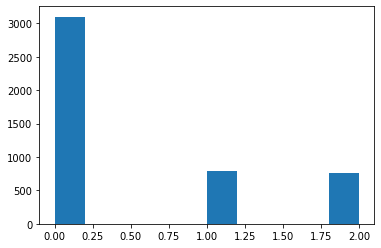

In [6]:
#训练集
EveluateLabel(labellist=TrainLabel)

样本标签统计: Counter({0: 664, 1: 169, 2: 164})


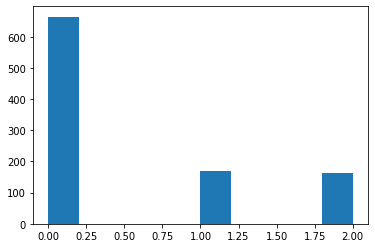

In [7]:
#验证集
EveluateLabel(labellist=ValidLabel)

样本标签统计: Counter({0: 664, 1: 170, 2: 164})


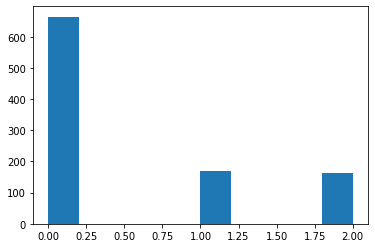

In [8]:
#测试集
EveluateLabel(labellist=TestLabel)

In [26]:
#编写数据读取函数
import tensorflow as tf
def ReadImageData(path,ImageLabel):
        image_io=tf.io.read_file(path)    #读取文件
        image_data=tf.image.decode_png(image_io,channels=3)    #解码图像数据
        image_datare=tf.image.resize(image_data,(512,512))
        image_normal=tf.cast(image_datare, tf.float32)/255.0
        return (image_normal,ImageLabel)

In [27]:
#使用文件路径方法批量读取数据
#训练集
FilePathDataset_Train=tf.data.Dataset.from_tensor_slices((TrainPath,TrainLabel)).repeat(1)    #文件路径数据集
ImageDataset_Train=FilePathDataset_Train.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Train=ImageDataset_Train.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)
#验证集
FilePathDataset_Valid=tf.data.Dataset.from_tensor_slices((ValidPath,ValidLabel)).repeat(1)    #文件路径数据集
ImageDataset_Valid=FilePathDataset_Valid.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Valid=ImageDataset_Valid.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)
#测试集
FilePathDataset_Test=tf.data.Dataset.from_tensor_slices((TestPath,TestLabel)).repeat(1)    #文件路径数据集
ImageDataset_Test=FilePathDataset_Test.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Test=ImageDataset_Test.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)

模型性能评估函数

In [11]:
#使用评估函数评估模型性能
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score
def ShowDNNConfusionMatrix(Model,Dataset):
    #提取数据原始标签
    True_label=[]
    Proba=[]
    index_proba=[0,1,2]
    Predict_Label=[]
    for data,labelN in Dataset:
        Predict_Proba=Model.predict(data)
        for proba,label in zip(Predict_Proba,labelN):
            True_label.append(label)
            index=np.argmax(proba)
            label=index_proba[index]
            Predict_Label.append(label)
    Label=np.array(True_label)
    PredictLabel=np.array(Predict_Label)
    TestPrecision=precision_score(Label,PredictLabel,average='micro')
    TestRecall=recall_score(Label,PredictLabel,average='micro')
    TestF1=f1_score(Label,PredictLabel,average='micro')
    TestAccuracy=accuracy_score(Label,PredictLabel)
    print('模型测试集Precision:{0},Recall:{1},F1_score:{2},Accuracy:{3}'.format(TestPrecision,TestRecall,TestF1,TestAccuracy))
    print('-------------------数据集混淆举证-------------------')
    ConfusionMatrix_result=confusion_matrix(Label,PredictLabel,labels=[0,1,2])    #计算混淆举证
    Display_ConfusionMatrix=ConfusionMatrixDisplay(ConfusionMatrix_result,display_labels=['Normal','Ischemia','Bleeding'])
    Display_ConfusionMatrix.plot(include_values=True, cmap='viridis', xticks_rotation='horizontal', values_format='d', ax=None)
    plt.title('Confusion Matrix')
    plt.show()

In [12]:
from sklearn.metrics import classification_report
from scipy.stats import chi2_contingency
from pandas import DataFrame
def ClassReport_X2(Model,Dataset):
    #提取数据原始标签
    True_label=[]
    Proba=[]
    index_proba=[0,1,2]
    Predict_Label=[]
    for data,labelN in Dataset:
        Predict_Proba=Model.predict(data)
        for proba,label in zip(Predict_Proba,labelN):
            True_label.append(label)
            index=np.argmax(proba)
            label=index_proba[index]
            Predict_Label.append(label)
    Label=np.array(True_label)
    PredictLabel=np.array(Predict_Label)
    print('-------------------数据集分类报告-------------------')
    print(classification_report(Label,PredictLabel,target_names=['Normal','Ischemia','Bleeding']))
    contingency_table = pd.crosstab(Label,PredictLabel, rownames=['True Label'], colnames=['Predict Label'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print('-------------------预测标签与真实标签卡方检验结果-------------------')
    print('卡方值为:{0},p值为:{1},自由度为:{2}'.format(chi2,p_value,dof))
    print('-------------------列联表-------------------')
    return DataFrame(contingency_table)

加载模型:CerebriScan_V2，并评估CereBriScan_V2模型性能.

In [13]:
#构建卷积神经网络专家模型
from tensorflow import keras
#Input shape[512,512,3];Output shape[14,14,64]
def ConvD2DModel(activation):
    EncoderImage=keras.models.Sequential([])
    EncoderImage.add(keras.layers.Input(shape=[512,512,3]))
    #Conv2D Blocks1 300--148
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks2 148--72
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks3 72--34
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks4 34--15
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(2,2),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2),padding='valid',data_format='channels_last',name='Output_Encoder'))
    return EncoderImage

In [14]:
#定义卷积路由器
class ConvidRounter(keras.layers.Layer):
    def __init__(self,ImageShape,**kwargs):
        super().__init__(**kwargs)
        #卷积Router参数
        self.ImageShape=ImageShape    #输入图像大小
        #定义卷积Router模块
        self.InputLayer = keras.layers.InputLayer(input_shape=self.ImageShape)
        self.Conv2DInput=keras.layers.Conv2D(filters=20,kernel_size=(3,3),strides=(2,2),activation='relu',padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',
                                             bias_initializer='zeros',input_shape=self.ImageShape)
        self.Conv2D2=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D3=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.MaxPooling=keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', data_format='channels_last')
        self.Conv2D4=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D5=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Flatten=keras.layers.Flatten()
        self.Dense=keras.layers.Dense(units=128, activation='relu',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
        self.Problity=keras.layers.Dense(units=4,activation='softmax',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
    def call(self,inputs):
        Input=self.InputLayer(inputs)
        Conv2DOut1=self.Conv2DInput(Input)    #卷积模块
        Conv2DOut2=self.Conv2D2(Conv2DOut1)
        Conv2DOut3=self.Conv2D3(Conv2DOut2)
        MaxPool1=self.MaxPooling(Conv2DOut3)
        Conv2DOut4=self.Conv2D4(MaxPool1)
        Conv2DOut5=self.Conv2D5(Conv2DOut4)
        MaxPool2=self.MaxPooling(Conv2DOut5)    #Outshape[3,5,20]
        FlattenOut=self.Flatten(MaxPool2)
        DenseOut1=self.Dense(FlattenOut)
        ProbilityOut1=self.Problity(DenseOut1)    #Outshape[batch,4]
        return ProbilityOut1
    def compute_output_shape(self):
        return tf.TensorShape([-1,4])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'ImageShape':self.ImageShape}

In [15]:
#基于MoE架构构建卷积MoE层
import tensorflow
from tensorflow import keras
class ConvidMoELayer(keras.layers.Layer):
    def __init__(self,Runter,Expoer1,Expoer2,Expoer3,Expoer4,**kwargs):
        super().__init__(**kwargs)
        self.Runter=Runter    #定义路由器模型
        #专家模型
        self.ConvidExpert1=Expoer1
        self.ConvidExpert2=Expoer2
        self.ConvidExpert3=Expoer3
        self.ConvidExpert4=Expoer4
    def call(self,inputs):
        #路由器模型输出概率
        RouterProblityOut=self.Runter(inputs)
        #计算专家模型输出 输入数据[512, 512,3]
        #Expert1
        Expert1Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert2
        Expert2Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert3
        Expert3Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert4
        Expert4Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #整合专家模型输出结果
        ExpertOut=[Expert1Out,Expert2Out,Expert3Out,Expert4Out]    #输出[batch_size, 14, 14，64]
        # 将路由器输出的概率值扩展为与专家输出相同的维度
        router_output_expanded=tf.expand_dims(RouterProblityOut, axis=1)  # [batch_size, 1, 4]
        router_output_expanded=tf.expand_dims(router_output_expanded, axis=1)  # [batch_size, 1, 1, 4]
        router_output_expanded=tf.tile(router_output_expanded, [1, 14, 14, 1])  # [batch_size, 14, 14, 4]
        #将专家输出与路由器概率相乘
        weighted_expert_outputs=[expert_output * router_output_expanded[:, :, :, i:i+1] for i, expert_output in enumerate(ExpertOut)]
        # 展开通道维度并拼接
        reshaped_outputs = [tf.reshape(output, [-1, 14, 896]) for output in weighted_expert_outputs]  # 形状为[batch_size, 14,896]
        MoEOut= tf.concat(reshaped_outputs, axis=1)  # 形状为[batch_size,56,896]
        return MoEOut
    def compute_output_shape(self):
        return tf.TensorShape([56,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'Runter':self.Runter,'Expoer1':self.ConvidExpert1,'Expoer2':self.ConvidExpert2,'Expoer3':self.ConvidExpert3,
                'Expoer4':self.ConvidExpert4}

In [16]:
#定义SwiGLU激活单元
class SwiGLU(keras.layers.Layer):
    def __init__(self,input_dim,output_dim,**kwargs):
        #input [batchsize,input_dim]"
         #Output [batchsize,input_dim]
        super().__init__(**kwargs)
        self.input_dim=input_dim    #输入维度
        self.output_dim=output_dim   #输出维度
        self.linear1=keras.layers.Dense(input_dim=self.input_dim,units=self.output_dim)
        self.linear2=keras.layers.Dense(input_dim=self.input_dim,units=self.output_dim)
        self.linear3=keras.layers.Dense(input_dim=self.output_dim,units=self.input_dim)
    def call(self,inputs):
        x1=self.linear1(inputs)
        x2=self.linear2(inputs)
        swish_x1=tf.nn.swish(x1)
        SwishGLU=swish_x1*x2
        Output=self.linear3(SwishGLU)
        return Output
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.input_dim,self.input_dim])
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'input_dim':self.input_dim,'output_dim':self.output_dim}

In [17]:
#构建基于AugResEncoder层 
class AugResEncoder(keras.layers.Layer):
    def __init__(self,heads,key_dim,input_dim,Wdim,deep_dim,SwiGLU,**kwargs):
        super().__init__(**kwargs)
        self.heads=heads    #注意力头数
        self.key_d=key_dim    #Key维度
        self.input_dim=input_dim    #输入数据维度
        self.Wdim=Wdim    #矩阵维度
        self.deep_dim=deep_dim    #FFN维度升高
        self.SwiGLU=SwiGLU    #SwiGLU激活单元
        self.Multi_Head_Attention=keras.layers.MultiHeadAttention(num_heads=self.heads,key_dim=self.key_d)    #自注意力
        self.LayerNormaltion=keras.layers.LayerNormalization()    #层归一化
        self.LinearLayer1=keras.layers.Dense(input_dim=self.input_dim,units=self.Wdim,activation=None,use_bias=False)    #线性层    [input_dim---Wdim]
        self.Relu=keras.layers.ReLU()    #Relu激活函数
        self.LinearActivation=keras.layers.Dense(input_dim=self.Wdim,units=self.deep_dim,activation='selu',    #[Wdim---deep_dim]
                                                 kernel_initializer=None,use_bias=False)    #使用SELU激活函数的线性层
        self.LinearLayer2=keras.layers.Dense(input_dim=self.deep_dim,units=self.Wdim,activation=None,use_bias=False)    #线性层    [deep_dim---input_dim]
        self.AddLayer=keras.layers.Add()    #相加层
    def call(self,inputs):    #前向计算    [input_dim,Wdim]
        LayerNormal1=self.LayerNormaltion(inputs)
        MSA=self.Multi_Head_Attention(query=LayerNormal1,value=LayerNormal1,key=LayerNormal1)    #计算Multi-Head-attention
        ResLinear1=self.LinearLayer1(LayerNormal1)
        ResActivation=self.LinearActivation(ResLinear1) 
        ResLinear2=self.LinearLayer2(ResActivation)    #ResNet模块  
        ResAdd=self.AddLayer([ResLinear2,LayerNormal1])
        ResRelu=self.Relu(ResAdd)
        ResNet=self.AddLayer([MSA,ResRelu])    #残差连接
        #FFN模块
        LayerNormal2=self.LayerNormaltion(ResNet)
        LinearOutput1=self.LinearLayer1(LayerNormal2)    #self.input_dim >> self.Wdim
        LinearActiontion=self.LinearActivation(LinearOutput1)
        LeakyRelu=self.Relu(LinearActiontion)
        LinearOutput2=self.LinearLayer2(LeakyRelu)
        SwiGLU=self.SwiGLU(LayerNormal2)    #self.Wdim >> self.Wdim
        ResNet2=self.AddLayer([LinearOutput2,SwiGLU,LayerNormal2])
        return ResNet2
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.input_dim,self.Wdim])
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'heads':self.heads,'key_dim':self.key_d,'input_dim':self.input_dim,'Wdim':self.Wdim,'deep_dim':self.deep_dim,'SwiGLU':self.SwiGLU}

In [18]:
#定义分类模块
def ClassModuleBluid():
    ClassModule=keras.models.Sequential([])
    ClassModule.add(keras.layers.Dense(units=300,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=150,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=100,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=50,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    return ClassModule

In [19]:
#加载CereBriScan_V1模型
from tensorflow import keras
custom_layer={'ConvD2DModel':ConvD2DModel,'ConvidRounter':ConvidRounter,'ConvidMoELayer':ConvidMoELayer,'SwiGLU':SwiGLU,
              'AugResEncoder':AugResEncoder,'ClassModuleBluid':ClassModuleBluid}
CereBriScan_V2=keras.models.load_model('/root/autodl-tmp/Base_Models/CerebriScan_V2.h5',custom_objects=custom_layer)

In [28]:
#在训练集上评估
CereBriScan_V2.evaluate(ImageDataset_Train,return_dict=True)

94/94 [==============================] - 35s 368ms/step - loss: 0.0023 - accuracy: 0.9996


{'loss': 0.002327724825590849, 'accuracy': 0.999570369720459}

In [29]:
#计算验证集Accuracy
CereBriScan_V2.evaluate(ImageDataset_Valid,return_dict=True)

20/20 [==============================] - 8s 368ms/step - loss: 0.2306 - accuracy: 0.9398


{'loss': 0.23059922456741333, 'accuracy': 0.9398194551467896}

In [30]:
#计算测试集Accuracy
CereBriScan_V2.evaluate(ImageDataset_Test,return_dict=True)

20/20 [==============================] - 8s 370ms/step - loss: 0.3067 - accuracy: 0.9379


{'loss': 0.30665311217308044, 'accuracy': 0.9378757476806641}

1/1 [==============================] - 0s 89ms/step
模型测试集Precision:0.9995703544575725,Recall:0.9995703544575725,F1_score:0.9995703544575725,Accuracy:0.9995703544575725
-------------------数据集混淆举证-------------------


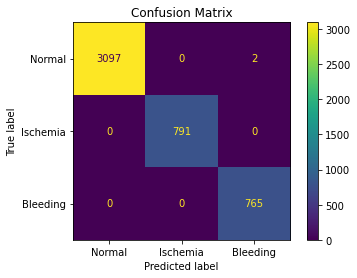

In [31]:
#训练集
ShowDNNConfusionMatrix(Model=CereBriScan_V2,Dataset=ImageDataset_Train)

2/2 [==============================] - 1s 375ms/step
模型测试集Precision:0.9398194583751254,Recall:0.9398194583751254,F1_score:0.9398194583751254,Accuracy:0.9398194583751254
-------------------数据集混淆举证-------------------


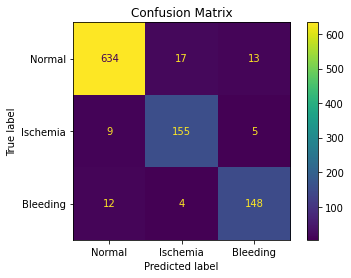

In [32]:
#验证集
ShowDNNConfusionMatrix(Model=CereBriScan_V2,Dataset=ImageDataset_Valid)

2/2 [==============================] - 1s 381ms/step
模型测试集Precision:0.9378757515030061,Recall:0.9378757515030061,F1_score:0.9378757515030061,Accuracy:0.9378757515030061
-------------------数据集混淆举证-------------------


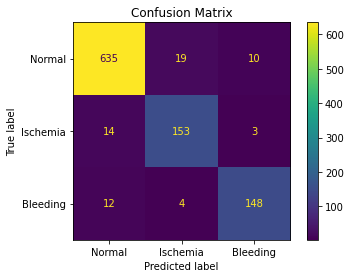

In [33]:
#测试集
ShowDNNConfusionMatrix(Model=CereBriScan_V2,Dataset=ImageDataset_Test)

In [40]:
#训练集
DTV2=ClassReport_X2(Model=CereBriScan_V2,Dataset=ImageDataset_Train)

1/1 [==============================] - 0s 89ms/step
-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3099
    Ischemia       1.00      1.00      1.00       791
    Bleeding       1.00      1.00      1.00       765

    accuracy                           1.00      4655
   macro avg       1.00      1.00      1.00      4655
weighted avg       1.00      1.00      1.00      4655

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:9294.865437940405,p值为:0.0,自由度为:4
-------------------列联表-------------------


In [41]:
DTV2

Predict Label,0,1,2
True Label,,,
0,3097,0,2
1,0,791,0
2,0,0,765


In [36]:
#验证集
DVV2=ClassReport_X2(Model=CereBriScan_V2,Dataset=ImageDataset_Valid)

2/2 [==============================] - 1s 136ms/step
-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96       664
    Ischemia       0.88      0.92      0.90       169
    Bleeding       0.89      0.90      0.90       164

    accuracy                           0.94       997
   macro avg       0.91      0.92      0.92       997
weighted avg       0.94      0.94      0.94       997

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:1539.4086831104973,p值为:0.0,自由度为:4
-------------------列联表-------------------


In [37]:
DVV2

Predict Label,0,1,2
True Label,,,
0,634,17,13
1,9,155,5
2,12,4,148


In [38]:
#测试集
DEV2=ClassReport_X2(Model=CereBriScan_V2,Dataset=ImageDataset_Test)

2/2 [==============================] - 1s 140ms/step
-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       664
    Ischemia       0.87      0.90      0.88       170
    Bleeding       0.92      0.90      0.91       164

    accuracy                           0.94       998
   macro avg       0.92      0.92      0.92       998
weighted avg       0.94      0.94      0.94       998

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:1535.569454496292,p值为:0.0,自由度为:4
-------------------列联表-------------------


In [39]:
DEV2

Predict Label,0,1,2
True Label,,,
0,635,19,10
1,14,153,3
2,12,4,148


加载模型:CerebriScan_V3，并评估CereBriScan_V3模型性能.

In [13]:
#构建卷积神经网络专家模型
from tensorflow import keras
#Input shape[512,512,3];Output shape[14,14,64]
def ConvD2DModel(activation):
    EncoderImage=keras.models.Sequential([])
    EncoderImage.add(keras.layers.Input(shape=[512,512,3]))
    #Conv2D Blocks1 300--148
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks2 148--72
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks3 72--34
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks4 34--15
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(2,2),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2),padding='valid',data_format='channels_last',name='Output_Encoder'))
    return EncoderImage

In [14]:
#定义卷积路由器
class ConvidRounter(keras.layers.Layer):
    def __init__(self,ImageShape,**kwargs):
        super().__init__(**kwargs)
        #卷积Router参数
        self.ImageShape=ImageShape    #输入图像大小
        #定义卷积Router模块
        self.InputLayer = keras.layers.InputLayer(input_shape=self.ImageShape)
        self.Conv2DInput=keras.layers.Conv2D(filters=20,kernel_size=(3,3),strides=(2,2),activation='relu',padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',
                                             bias_initializer='zeros',input_shape=self.ImageShape)
        self.Conv2D2=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D3=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.MaxPooling=keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', data_format='channels_last')
        self.Conv2D4=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D5=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Flatten=keras.layers.Flatten()
        self.Dense=keras.layers.Dense(units=128, activation='relu',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
        self.Problity=keras.layers.Dense(units=4,activation='softmax',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
    def call(self,inputs):
        Input=self.InputLayer(inputs)
        Conv2DOut1=self.Conv2DInput(Input)    #卷积模块
        Conv2DOut2=self.Conv2D2(Conv2DOut1)
        Conv2DOut3=self.Conv2D3(Conv2DOut2)
        MaxPool1=self.MaxPooling(Conv2DOut3)
        Conv2DOut4=self.Conv2D4(MaxPool1)
        Conv2DOut5=self.Conv2D5(Conv2DOut4)
        MaxPool2=self.MaxPooling(Conv2DOut5)    #Outshape[3,5,20]
        FlattenOut=self.Flatten(MaxPool2)
        DenseOut1=self.Dense(FlattenOut)
        ProbilityOut1=self.Problity(DenseOut1)    #Outshape[batch,4]
        return ProbilityOut1
    def compute_output_shape(self):
        return tf.TensorShape([-1,4])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'ImageShape':self.ImageShape}

In [15]:
#基于MoE架构构建卷积MoE层
import tensorflow
from tensorflow import keras
class ConvidMoELayer(keras.layers.Layer):
    def __init__(self,Runter,Expoer1,Expoer2,Expoer3,Expoer4,**kwargs):
        super().__init__(**kwargs)
        self.Runter=Runter    #定义路由器模型
        #专家模型
        self.ConvidExpert1=Expoer1
        self.ConvidExpert2=Expoer2
        self.ConvidExpert3=Expoer3
        self.ConvidExpert4=Expoer4
    def call(self,inputs):
        #路由器模型输出概率
        RouterProblityOut=self.Runter(inputs)
        #计算专家模型输出 输入数据[512, 512,3]
        #Expert1
        Expert1Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert2
        Expert2Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert3
        Expert3Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert4
        Expert4Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #整合专家模型输出结果
        ExpertOut=[Expert1Out,Expert2Out,Expert3Out,Expert4Out]    #输出[batch_size, 14, 14，64]
        # 将路由器输出的概率值扩展为与专家输出相同的维度
        router_output_expanded=tf.expand_dims(RouterProblityOut, axis=1)  # [batch_size, 1, 4]
        router_output_expanded=tf.expand_dims(router_output_expanded, axis=1)  # [batch_size, 1, 1, 4]
        router_output_expanded=tf.tile(router_output_expanded, [1, 14, 14, 1])  # [batch_size, 14, 14, 4]
        #将专家输出与路由器概率相乘
        weighted_expert_outputs=[expert_output * router_output_expanded[:, :, :, i:i+1] for i, expert_output in enumerate(ExpertOut)]
        # 展开通道维度并拼接
        reshaped_outputs = [tf.reshape(output, [-1, 14, 896]) for output in weighted_expert_outputs]  # 形状为[batch_size, 14,896]
        MoEOut= tf.concat(reshaped_outputs, axis=1)  # 形状为[batch_size,56,896]
        return MoEOut
    def compute_output_shape(self):
        return tf.TensorShape([56,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'Runter':self.Runter,'Expoer1':self.ConvidExpert1,'Expoer2':self.ConvidExpert2,'Expoer3':self.ConvidExpert3,
                'Expoer4':self.ConvidExpert4}

In [16]:
#定义SwiGLU激活单元
class SwiGLU(keras.layers.Layer):
    def __init__(self,input_dim,output_dim,**kwargs):
        #input [batchsize,input_dim]"
         #Output [batchsize,input_dim]
        super().__init__(**kwargs)
        self.input_dim=input_dim    #输入维度
        self.output_dim=output_dim   #输出维度
        self.linear1=keras.layers.Dense(input_dim=self.input_dim,units=self.output_dim)
        self.linear2=keras.layers.Dense(input_dim=self.input_dim,units=self.output_dim)
        self.linear3=keras.layers.Dense(input_dim=self.output_dim,units=self.input_dim)
    def call(self,inputs):
        x1=self.linear1(inputs)
        x2=self.linear2(inputs)
        swish_x1=tf.nn.swish(x1)
        SwishGLU=swish_x1*x2
        Output=self.linear3(SwishGLU)
        return Output
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.input_dim,self.input_dim])
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'input_dim':self.input_dim,'output_dim':self.output_dim}

In [17]:
#构建基于AugResEncoder层 
class AugResEncoder(keras.layers.Layer):
    def __init__(self,heads,key_dim,input_dim,Wdim,deep_dim,SwiGLU,**kwargs):
        super().__init__(**kwargs)
        self.heads=heads    #注意力头数
        self.key_d=key_dim    #Key维度
        self.input_dim=input_dim    #输入数据维度
        self.Wdim=Wdim    #矩阵维度
        self.deep_dim=deep_dim    #FFN维度升高
        self.SwiGLU=SwiGLU    #SwiGLU激活单元
        self.Multi_Head_Attention=keras.layers.MultiHeadAttention(num_heads=self.heads,key_dim=self.key_d)    #自注意力
        self.LayerNormaltion=keras.layers.LayerNormalization()    #层归一化
        self.LinearLayer1=keras.layers.Dense(input_dim=self.input_dim,units=self.Wdim,activation=None,use_bias=False)    #线性层    [input_dim---Wdim]
        self.Relu=keras.layers.ReLU()    #Relu激活函数
        self.LinearActivation=keras.layers.Dense(input_dim=self.Wdim,units=self.deep_dim,activation='selu',    #[Wdim---deep_dim]
                                                 kernel_initializer=None,use_bias=False)    #使用SELU激活函数的线性层
        self.LinearLayer2=keras.layers.Dense(input_dim=self.deep_dim,units=self.Wdim,activation=None,use_bias=False)    #线性层    [deep_dim---input_dim]
        self.AddLayer=keras.layers.Add()    #相加层
    def call(self,inputs):    #前向计算    [input_dim,Wdim]
        LayerNormal1=self.LayerNormaltion(inputs)
        MSA=self.Multi_Head_Attention(query=LayerNormal1,value=LayerNormal1,key=LayerNormal1)    #计算Multi-Head-attention
        ResLinear1=self.LinearLayer1(LayerNormal1)
        ResActivation=self.LinearActivation(ResLinear1) 
        ResLinear2=self.LinearLayer2(ResActivation)    #ResNet模块  
        ResAdd=self.AddLayer([ResLinear2,LayerNormal1])
        ResRelu=self.Relu(ResAdd)
        ResNet=self.AddLayer([MSA,ResRelu])    #残差连接
        #FFN模块
        LayerNormal2=self.LayerNormaltion(ResNet)
        #LinearOutput1=self.LinearLayer1(LayerNormal2)    #self.input_dim >> self.Wdim
        #LinearActiontion=self.LinearActivation(LinearOutput1)
        #LeakyRelu=self.Relu(LinearActiontion)
        #LinearOutput2=self.LinearLayer2(LeakyRelu)
        SwiGLU=self.SwiGLU(LayerNormal2)    #self.Wdim >> self.Wdim
        ResNet2=self.AddLayer([SwiGLU,LayerNormal2])
        return ResNet2
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.input_dim,self.Wdim])
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'heads':self.heads,'key_dim':self.key_d,'input_dim':self.input_dim,'Wdim':self.Wdim,'deep_dim':self.deep_dim,'SwiGLU':self.SwiGLU}

In [18]:
#定义分类模块
def ClassModuleBluid():
    ClassModule=keras.models.Sequential([])
    ClassModule.add(keras.layers.Dense(units=300,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=150,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=100,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=50,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    return ClassModule

In [19]:
#加载CerebriScan_V3模型
custom_layer={'ConvD2DModel':ConvD2DModel,'ConvidRounter':ConvidRounter,'ConvidMoELayer':ConvidMoELayer,'SwiGLU':SwiGLU,
              'AugResEncoder':AugResEncoder,'ClassModuleBluid':ClassModuleBluid}
CereBriScan_V3=keras.models.load_model('/root/autodl-tmp/Base_Models/CerebriScan_V3.h5',custom_objects=custom_layer)

In [20]:
#在训练集上评估
CereBriScan_V3.evaluate(ImageDataset_Train,return_dict=True)

2025-08-05 15:59:41.833861: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101


94/94 [==============================] - 39s 359ms/step - loss: 0.0014 - accuracy: 1.0000


{'loss': 0.0014468918088823557, 'accuracy': 1.0}

In [21]:
#评估验证集Accuracy
CereBriScan_V3.evaluate(ImageDataset_Valid,return_dict=True)

20/20 [==============================] - 9s 427ms/step - loss: 0.3964 - accuracy: 0.9097


{'loss': 0.3963797986507416, 'accuracy': 0.9097291827201843}

In [22]:
#计算训练集Accuracy
CereBriScan_V3.evaluate(ImageDataset_Test,return_dict=True)

20/20 [==============================] - 8s 391ms/step - loss: 0.4017 - accuracy: 0.9138


{'loss': 0.4017496705055237, 'accuracy': 0.913827657699585}

1/1 [==============================] - 0s 93ms/step
模型测试集Precision:1.0,Recall:1.0,F1_score:1.0,Accuracy:1.0
-------------------数据集混淆举证-------------------


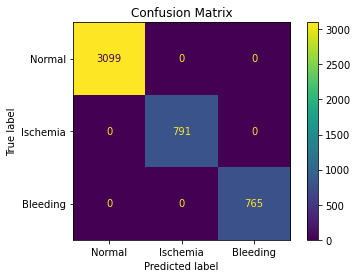

In [23]:
#训练集
ShowDNNConfusionMatrix(Model=CereBriScan_V3,Dataset=ImageDataset_Train)

2/2 [==============================] - 1s 371ms/step
模型测试集Precision:0.9097291875626881,Recall:0.9097291875626881,F1_score:0.9097291875626881,Accuracy:0.9097291875626881
-------------------数据集混淆举证-------------------


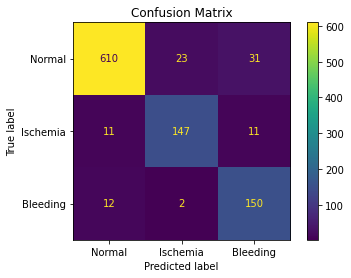

In [24]:
#验证集
ShowDNNConfusionMatrix(Model=CereBriScan_V3,Dataset=ImageDataset_Valid)

2/2 [==============================] - 1s 373ms/step
模型测试集Precision:0.9138276553106213,Recall:0.9138276553106213,F1_score:0.9138276553106213,Accuracy:0.9138276553106213
-------------------数据集混淆举证-------------------


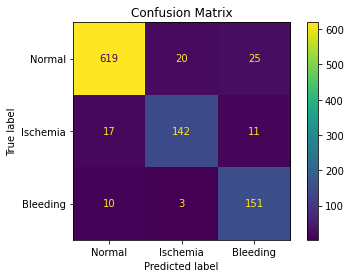

In [25]:
#测试集
ShowDNNConfusionMatrix(Model=CereBriScan_V3,Dataset=ImageDataset_Test)

In [26]:
#训练集
DT=ClassReport_X2(Model=CereBriScan_V3,Dataset=ImageDataset_Train)

1/1 [==============================] - 0s 91ms/step
-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3099
    Ischemia       1.00      1.00      1.00       791
    Bleeding       1.00      1.00      1.00       765

    accuracy                           1.00      4655
   macro avg       1.00      1.00      1.00      4655
weighted avg       1.00      1.00      1.00      4655

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:9310.0,p值为:0.0,自由度为:4
-------------------列联表-------------------


In [27]:
DT

Predict Label,0,1,2
True Label,,,
0,3099,0,0
1,0,791,0
2,0,0,765


In [28]:
#验证集
DV=ClassReport_X2(Model=CereBriScan_V3,Dataset=ImageDataset_Valid)

2/2 [==============================] - 1s 126ms/step
-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.96      0.92      0.94       664
    Ischemia       0.85      0.87      0.86       169
    Bleeding       0.78      0.91      0.84       164

    accuracy                           0.91       997
   macro avg       0.87      0.90      0.88       997
weighted avg       0.92      0.91      0.91       997

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:1357.7209578512457,p值为:1.016388672531385e-292,自由度为:4
-------------------列联表-------------------


In [29]:
DV 

Predict Label,0,1,2
True Label,,,
0,610,23,31
1,11,147,11
2,12,2,150


In [30]:
#测试集
DE=ClassReport_X2(Model=CereBriScan_V3,Dataset=ImageDataset_Test)

2/2 [==============================] - 1s 131ms/step
-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.96      0.93      0.95       664
    Ischemia       0.86      0.84      0.85       170
    Bleeding       0.81      0.92      0.86       164

    accuracy                           0.91       998
   macro avg       0.88      0.90      0.88       998
weighted avg       0.92      0.91      0.91       998

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:1369.2582744436982,p值为:3.202084732654344e-295,自由度为:4
-------------------列联表-------------------


In [31]:
DE

Predict Label,0,1,2
True Label,,,
0,619,20,25
1,17,142,11
2,10,3,151


使用CerebriScan V2模型作为基础模型进行训练